#####**Observação:** Usaremos todos os dados desses 2 meses.

#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up) e Ni (up202205842)

18.   **Experimento 6.1 - Pipeline de Machine Learning**

Tarefa ML: Prever `fare_amount` (tarifa da viagem)

| Modelo | Tipo | Alvo |
|---|---|---|
| **XGBRegressor** | Regressão | `fare_amount` contínuo |
| **LogisticRegression** | Classificação | `fare_amount` discretizado em 4 classes |

Escalabilidade e configuração do dataset

Nesta versão do pipeline, foi adotada uma abordagem de escala maior, com o objetivo de explorar o limite de memória do Google Colab Free.

Tamanho do dataset
- Utilizada uma amostra de aproximadamente 4.000.000 registos.

>18.1.   **Configuração do Ambiente**


Instalação da biblioteca de processamento de dados:


In [1]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================

# !pip install dask[complete] pyarrow          # Dask
#!pip install modin[ray]                      # Modin (backend Ray)
# !pip install pyspark                         # PySpark / Koalas
# !pip install xgboost                         # XGBoost
# !pip install yappi                           # Profiling multi-thread

# RAPIDS (só com GPU NVIDIA no Colab — ativar runtime GPU primeiro):
#!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

print("OK.")

OK.


Iniciando a leitura com algumas importações necessárias:

In [2]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 19:09


In [3]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}

# --- Dask ---
try:
    import dask.dataframe as dd
    import dask
    print(f"Dask        : {dask.__version__}")
    DASK_AVAILABLE = True
except ImportError:
    print("Dask não disponível")
    DASK_AVAILABLE = False

# --- Modin (Ray como backend default) ---
# [ADICIONADO] — Modin não estava no notebook original
#try:
#    import modin.pandas as mpd
#    import modin
#    print(f" Modin       : {modin.__version__}")
#    MODIN_AVAILABLE = True
#except ImportError:
#    print(" Modin não disponível (pip install modin[ray])")
#    MODIN_AVAILABLE = False
#import ray


#if ray.is_initialized():
    #ray.shutdown()

# Força o Ray a respeitar os limites apertados do Colab gratuito
#  ray.init(
#    num_cpus=2,                     # O Colab gratuito só tem 2 vCPUs
#   object_store_memory=2 * 1024 * 1024 * 1024, # Limita o cache do Ray a 2 GB (evita estouro)
#   _memory=4 * 1024 * 1024 * 1024  # Limita a memória de trabalho a 4 GB
#)


# --- PySpark / Koalas ---
try:
    import pyspark.pandas as ps
    from pyspark.sql import SparkSession
    import pyspark
    print(f" PySpark     : {pyspark.__version__}")
    SPARK_AVAILABLE = True
except Exception as e:
    print(f" PySpark não disponível: {str(e)[:60]}")
    SPARK_AVAILABLE = False

# --- JobLib (já incluído no Scikit-learn, mas importamos explicitamente) ---
# [ADICIONADO] — JobLib não estava no notebook original
try:
    import joblib
    print(f" JobLib      : {joblib.__version__}")
    JOBLIB_AVAILABLE = True
except ImportError:
    print(" JobLib não disponível")
    JOBLIB_AVAILABLE = False

# --- RAPIDS cuDF (GPU) ---
# [ADICIONADO] — Rapids não estava no notebook original
try:
    import cudf
    print(f" cuDF (GPU)  : {cudf.__version__}")
    CUDF_AVAILABLE = True
except ImportError:
    print(" cuDF não disponível (sem GPU NVIDIA/CUDA)")
    CUDF_AVAILABLE = False

# --- XGBoost ---
# [ADICIONADO] — necessário para o Pipeline ML
try:
    import xgboost as xgb
    print(f" XGBoost     : {xgb.__version__}")
    XGB_AVAILABLE = True
except ImportError:
    print(" XGBoost não disponível (pip install xgboost)")
    XGB_AVAILABLE = False

# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

Dask        : 2026.3.0
 PySpark     : 4.0.2
 JobLib      : 1.5.3
 cuDF não disponível (sem GPU NVIDIA/CUDA)
 XGBoost     : 3.2.0
 Scikit-learn: 1.6.1


In [4]:
# ── [NOVO] Imports ML ───────────────────────────────────────
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV, GridSearchCV)
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (mean_squared_error, mean_absolute_error, r2_score,
                                     accuracy_score, precision_score, recall_score,
                                     f1_score, classification_report, confusion_matrix)
from sklearn.datasets        import load_iris
from sklearn.metrics import mean_squared_error


print(" Imports ML OK")

 Imports ML OK


In [5]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 12      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 12


In [6]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

A pasta está vazia.


In [7]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

In [8]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro



for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [9]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet ...
   Guardado: 64.2 MB
⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet ...
   Guardado: 58.7 MB
Processo de download concluído!


18.2   **Início das Operações**

Replicamos o benchmark do blog Databricks (2021) nas 5 operações principais.


In [10]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

In [11]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

In [12]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed

In [13]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet



18.2.1  **Task 1 — Leitura dos Dados (*Reading*)**


In [14]:
df, t_pandas = benchmark_pandas(caminho)
resultados.append(('Task 1 - Leitura', 'Pandas', round(t_pandas, 4)))  # substitui com o valor real
df.head()

Iniciando leitura com Pandas...

Resultado Pandas:
- Linhas: 7124755
- Colunas: 20
- Tempo: 4.82s


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,7,2026-02-01 00:05:57,2026-02-01 00:05:57,1.0,0.94,1.0,N,107,170,1,7.2,0.00,0.5,0.00,0.0,1.0,12.95,2.5,0.00,0.75
1,7,2026-02-01 00:35:58,2026-02-01 00:35:58,1.0,1.93,1.0,N,234,141,1,11.4,0.00,0.5,3.43,0.0,1.0,20.58,2.5,0.00,0.75
2,2,2026-02-01 00:08:41,2026-02-01 00:39:32,1.0,9.99,1.0,N,138,68,1,44.3,6.00,0.5,11.01,0.0,1.0,67.81,2.5,1.75,0.75
3,1,2026-02-01 00:29:06,2026-02-01 00:41:04,0.0,1.70,1.0,N,209,13,1,12.8,4.25,0.5,3.70,0.0,1.0,22.25,2.5,0.00,0.75
4,1,2026-02-01 00:53:52,2026-02-01 01:11:21,0.0,3.70,1.0,N,249,229,1,19.8,4.25,0.5,6.35,0.0,1.0,31.90,2.5,0.00,0.75


18.2.2  **Pré-processamento**
Seguindo a estrutura do enunciado: **limpeza → feature engineering → feature selection**.

In [15]:
# ── [NOVO] Pré-processamento ─────────────────────────────────
# Limpeza e criação de features a partir do dataset principal (df).
# Trabalhamos directamente em df para evitar cópias desnecessárias.

print("=" * 50)
print("PRÉ-PROCESSAMENTO")
print("=" * 50)

# ---- 1. Limpeza de outliers e valores inválidos ----
# Tarifas válidas: entre $2.5 (mínimo NYC Taxi) e $200
mask = (
    (df['fare_amount']    >= 2.5) & (df['fare_amount']    <= 200) &
    (df['trip_distance']  > 0)    & (df['trip_distance']  < 100)  &
    (df['passenger_count'] >= 1)  & (df['passenger_count'] <= 6)
)
df_clean = df.loc[mask].copy()   # .copy() apenas neste subset filtrado
print(f"Linhas após limpeza: {len(df_clean):,} (de {len(df):,} — {len(df_clean)/len(df)*100:.1f}% retidos)")

# Liberta o df original (já não é necessário)
del df
gc.collect()

# ---- 2. Feature Engineering ----
# Variáveis temporais extraídas do datetime de pickup
df_clean['tpep_pickup_datetime']  = pd.to_datetime(df_clean['tpep_pickup_datetime'],  errors='coerce')
df_clean['tpep_dropoff_datetime'] = pd.to_datetime(df_clean['tpep_dropoff_datetime'], errors='coerce')

df_clean['hora_pickup'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['dia_semana']  = df_clean['tpep_pickup_datetime'].dt.dayofweek  # 0=Segunda, 6=Domingo
df_clean['hora_pico']   = (df_clean['hora_pickup'].between(7, 9) | df_clean['hora_pickup'].between(16, 19)).astype(int)
df_clean['fim_semana']  = (df_clean['dia_semana'] >= 5).astype(int)

# Duração da viagem em minutos
df_clean['duracao_min'] = (
    df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Remove durações inválidas e velocidades irreais
df_clean = df_clean[(df_clean['duracao_min'] > 0) & (df_clean['duracao_min'] < 180)]
df_clean['velocidade_mph'] = df_clean['trip_distance'] / (df_clean['duracao_min'] / 60 + 0.001)
df_clean = df_clean[df_clean['velocidade_mph'] < 100]

print(f"Linhas após feature engineering: {len(df_clean):,}")
print("\nFeatures criadas: hora_pickup, dia_semana, hora_pico, fim_semana, duracao_min, velocidade_mph")

PRÉ-PROCESSAMENTO
Linhas após limpeza: 4,858,950 (de 7,124,755 — 68.2% retidos)
Linhas após feature engineering: 4,771,973

Features criadas: hora_pickup, dia_semana, hora_pico, fim_semana, duracao_min, velocidade_mph


In [16]:
# ── [NOVO] Seleção de Features e Split Treino/Teste ─────────
# Seleccionamos as features com maior correlação com fare_amount.
# Descartamos colunas com data leakage (ex: total_amount inclui fare_amount).

FEATURES = [
    'trip_distance',   # ★ Mais importante
    'duracao_min',     # ★ Muito correlacionado
    'hora_pickup',
    'dia_semana',
    'hora_pico',
    'fim_semana',
    'passenger_count',
    'PULocationID',
    'DOLocationID',
    'VendorID',
    'payment_type',
    'velocidade_mph',
]
TARGET = 'fare_amount'

# Verificar correlação
corr = df_clean[FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)
print("Correlação de Pearson com fare_amount:")
print(corr.to_string())

# ── Amostragem — CHAVE para não explodir a RAM do Colab ──────
# [NOVO]: SAMPLE_SIZE limita o dataset para o treino
# Colab free: use 30_000. Colab Pro: pode aumentar para 100_000+
SAMPLE_SIZE =   4000000 # ← AJUSTE AQUI conforme a RAM disponível

df_sample = df_clean[FEATURES + [TARGET]].dropna().sample(SAMPLE_SIZE, random_state=42)
print(f"\n Amostra de treino: {len(df_sample):,} registos (de {len(df_clean):,})")

# Features (X) e alvos (y)
X     = df_sample[FEATURES]
y_reg = df_sample[TARGET]

# Para classificação: discretizar fare_amount em 4 categorias
bins   = [0, 8, 14, 25, 200]
labels = [0,  1,  2,   3]    # 0=Barata, 1=Normal, 2=Cara, 3=Muito Cara
y_clf  = pd.cut(y_reg, bins=bins, labels=labels).astype(int)

print("\nDistribuição das classes (para classificação):")
print(y_clf.value_counts().sort_index().to_frame()
      .rename(index={0:'0 — Barata (<$8)', 1:'1 — Normal ($8-$14)',
                     2:'2 — Cara ($14-$25)', 3:'3 — Muito Cara (>$25)'}))

# Split 80/20 estratificado (mantém proporção de classes)
X_train, X_test, y_tr, y_te, y_tr_c, y_te_c = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

# Normalização (necessária para LogisticRegression)
scaler       = StandardScaler()
X_tr_sc      = scaler.fit_transform(X_train)
X_te_sc      = scaler.transform(X_test)

print(f"\nTreino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")

# Liberta df_clean — já não é necessário
del df_clean, df_sample
gc.collect()
print(" df_clean libertado — RAM preservada")

Correlação de Pearson com fare_amount:
fare_amount        1.000000
trip_distance      0.922026
duracao_min        0.773505
velocidade_mph     0.609424
passenger_count    0.051835
payment_type       0.012371
hora_pickup       -0.010729
hora_pico         -0.021442
VendorID          -0.030047
dia_semana        -0.030094
fim_semana        -0.032511
DOLocationID      -0.116889
PULocationID      -0.154542

 Amostra de treino: 4,000,000 registos (de 4,771,973)

Distribuição das classes (para classificação):
                         count
fare_amount                   
0 — Barata (<$8)        789533
1 — Normal ($8-$14)    1299631
2 — Cara ($14-$25)     1072379
3 — Muito Cara (>$25)   838457

Treino: 3,200,000 | Teste: 800,000
 df_clean libertado — RAM preservada


18.2.2  **Modelo 1 — XGBRegressor (Regressão)**

Prevê o valor exacto de `fare_amount`. Usa gradient boosting sobre árvores de decisão.

In [17]:
# ── [NOVO] XGBRegressor ──────────────────────────────────────
# RandomizedSearchCV: explora subconjunto aleatório dos hiperparâmetros.
# Muito mais rápido que GridSearch (n_iter=5, cv=3 para Colab free).
# [NOTA RAM]: n_jobs=1 evita spawn de múltiplos processos que explodem a RAM.
# Em Colab Pro ou GCP, pode usar n_jobs=-1.

print("=" * 50)
print("MODELO 1 — XGBRegressor (Regressão)")
print("=" * 50)

resultados_ml = []  # Tabela de métricas ML (separada do benchmark)

if XGB_AVAILABLE:
    # ── Hiperparâmetros a pesquisar ──────────────────────────
    # [MODIFICADO vs versão anterior]: grid reduzido para não explodir RAM
    param_xgb = {
        'n_estimators' : [100, 200],        # Antes: [100, 200, 300]
        'max_depth'    : [3, 5],            # Antes: [3, 5, 7]
        'learning_rate': [0.05, 0.1],       # Antes: [0.05, 0.1, 0.2]
        'subsample'    : [0.8, 1.0],
    }

    xgb_base = xgb.XGBRegressor(
        random_state=42,
        n_jobs=1,           # 1 para Colab free; -1 para Pro/GCP
        tree_method='hist'  # Mais rápido em CPU
    )

    xgb_search = RandomizedSearchCV(
        xgb_base, param_xgb,
        n_iter=5,           # [MODIFICADO]: era 10; reduzido para Colab free
        cv=3,               # [MODIFICADO]: era 5; reduzido para Colab free
        scoring='neg_root_mean_squared_error',
        n_jobs=1,           # [MODIFICADO]: era -1; 1 = sem fork de processos
        random_state=42, verbose=1
    )

    t0 = time.perf_counter()
    xgb_search.fit(X_train, y_tr)
    t_xgb = time.perf_counter() - t0

    melhor_xgb  = xgb_search.best_estimator_
    y_pred_xgb  = melhor_xgb.predict(X_test)

    rmse_xgb = np.sqrt(mean_squared_error(y_te, y_pred_xgb))
    mae_xgb  = mean_absolute_error(y_te, y_pred_xgb)
    r2_xgb   = r2_score(y_te, y_pred_xgb)

    print(f"\n Melhor hiperparâmetros: {xgb_search.best_params_}")
    print(f"   RMSE (CV treino): {-xgb_search.best_score_:.4f}")
    print(f"   Tempo de treino : {t_xgb:.2f}s")
    print(f"\n Métricas no TESTE:")
    print(f"   RMSE : {rmse_xgb:.4f} USD")
    print(f"   MAE  : {mae_xgb:.4f} USD")
    print(f"   R²   : {r2_xgb:.4f}")

    resultados_ml.append({'Modelo': 'XGBRegressor', 'Tipo': 'Regressão',
                          'RMSE': round(rmse_xgb,4), 'MAE': round(mae_xgb,4),
                          'R²': round(r2_xgb,4), 'Accuracy': None, 'F1': None,
                          'Tempo treino (s)': round(t_xgb,2)})
else:
    print(" XGBoost não disponível — pip install xgboost")

MODELO 1 — XGBRegressor (Regressão)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

 Melhor hiperparâmetros: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
   RMSE (CV treino): 3.8465
   Tempo de treino : 387.76s

 Métricas no TESTE:
   RMSE : 3.8475 USD
   MAE  : 1.1372 USD
   R²   : 0.9504


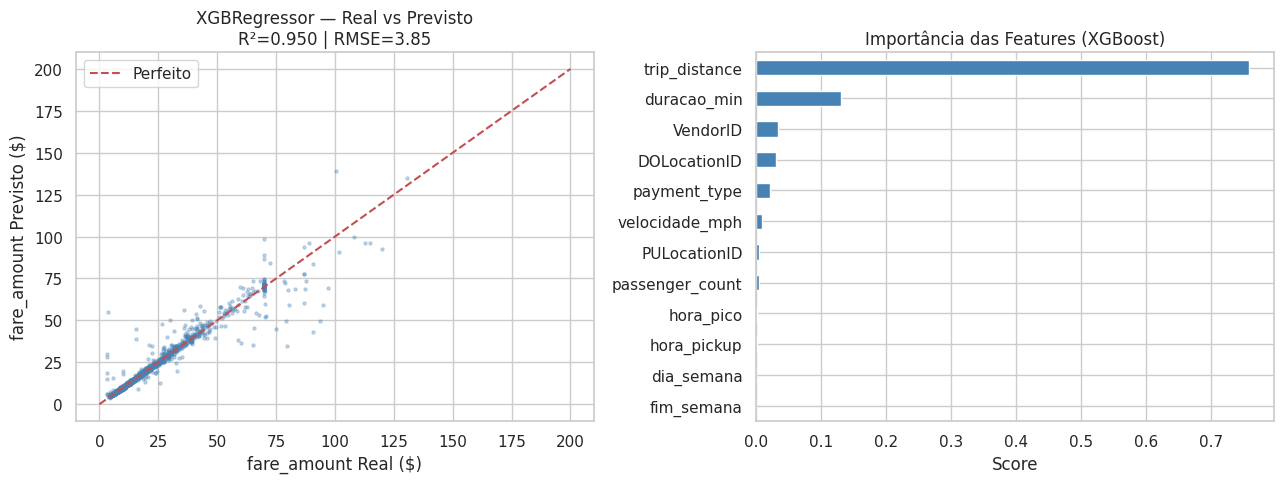

 Guardado: xgb_resultadosbigdata.png


In [18]:
# ── [NOVO] Visualizações XGBoost ────────────────────────────
if XGB_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Plot 1: Real vs Previsto
    idx_plot = np.random.choice(len(y_te), min(2000, len(y_te)), replace=False)
    axes[0].scatter(y_te.iloc[idx_plot], y_pred_xgb[idx_plot],
                    alpha=0.3, s=5, color='steelblue')
    lim = max(y_te.max(), y_pred_xgb.max())
    axes[0].plot([0, lim], [0, lim], 'r--', label='Perfeito')
    axes[0].set_xlabel('fare_amount Real ($)')
    axes[0].set_ylabel('fare_amount Previsto ($)')
    axes[0].set_title(f'XGBRegressor — Real vs Previsto\nR²={r2_xgb:.3f} | RMSE={rmse_xgb:.2f}')
    axes[0].legend()

    # Plot 2: Importância das features
    imp = pd.Series(melhor_xgb.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Importância das Features (XGBoost)')
    axes[1].set_xlabel('Score')

    plt.tight_layout()
    plt.savefig('./xgb_resultadosbigdata.png', dpi=150)
    plt.show()
    print(" Guardado: xgb_resultadosbigdata.png")

18.2.3  **Modelo 2 — LogisticRegression (Classificação)**

Classifica `fare_amount` em 4 categorias após discretização. Modelo linear → precisa de normalização.

In [19]:
# ── [NOVO] LogisticRegression ────────────────────────────────
# [MODIFICADO vs versão anterior]: grid muito reduzido para não explodir RAM.
# Antes: 4 valores de C × 2 solvers × 2 max_iter = 16 combinações × 5 folds.
# Agora:  2 valores de C × 1 solver × 1 max_iter  =  2 combinações × 3 folds.

print("=" * 50)
print("MODELO 2 — LogisticRegression (Classificação)")
print("=" * 50)
print("Alvo: fare_amount → 0=Barata | 1=Normal | 2=Cara | 3=Muito Cara")

param_lr = {
    'C'       : [0.1, 1.0],    # [MODIFICADO]: era [0.01, 0.1, 1.0, 10.0]
    'solver'  : ['lbfgs'],     # [MODIFICADO]: era ['lbfgs', 'saga']
    'max_iter': [500],
}

lr_base = LogisticRegression(multi_class='auto', random_state=42,
                              n_jobs=1)   # [MODIFICADO]: era n_jobs=-1

lr_search = GridSearchCV(
    lr_base, param_lr,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),  # [MODIFICADO]: era 5 folds
    scoring='accuracy',
    n_jobs=1,    # [MODIFICADO]: era -1
    verbose=0
)

t0 = time.perf_counter()
lr_search.fit(X_tr_sc, y_tr_c)
t_lr = time.perf_counter() - t0

melhor_lr  = lr_search.best_estimator_
y_pred_lr  = melhor_lr.predict(X_te_sc)

acc_lr  = accuracy_score(y_te_c, y_pred_lr)
prec_lr = precision_score(y_te_c, y_pred_lr, average='weighted', zero_division=0)
rec_lr  = recall_score(y_te_c, y_pred_lr, average='weighted', zero_division=0)
f1_lr   = f1_score(y_te_c, y_pred_lr, average='weighted', zero_division=0)

print(f"\n Melhor hiperparâmetros : {lr_search.best_params_}")
print(f"   Accuracy CV           : {lr_search.best_score_:.4f}")
print(f"   Tempo de treino       : {t_lr:.2f}s")
print(f"\n Métricas no TESTE:")
print(f"   Accuracy  : {acc_lr:.4f}")
print(f"   Precision : {prec_lr:.4f} (weighted)")
print(f"   Recall    : {rec_lr:.4f} (weighted)")
print(f"   F1-Score  : {f1_lr:.4f} (weighted)")
print("\n Relatório completo:")
print(classification_report(y_te_c, y_pred_lr,
      target_names=['Barata', 'Normal', 'Cara', 'Muito Cara']))

resultados_ml.append({'Modelo': 'LogisticRegression', 'Tipo': 'Classificação',
                      'RMSE': None, 'MAE': None, 'R²': None,
                      'Accuracy': round(acc_lr,4), 'F1': round(f1_lr,4),
                      'Tempo treino (s)': round(t_lr,2)})

MODELO 2 — LogisticRegression (Classificação)
Alvo: fare_amount → 0=Barata | 1=Normal | 2=Cara | 3=Muito Cara

 Melhor hiperparâmetros : {'C': 1.0, 'max_iter': 500, 'solver': 'lbfgs'}
   Accuracy CV           : 0.9482
   Tempo de treino       : 493.64s

 Métricas no TESTE:
   Accuracy  : 0.9485
   Precision : 0.9488 (weighted)
   Recall    : 0.9485 (weighted)
   F1-Score  : 0.9485 (weighted)

 Relatório completo:
              precision    recall  f1-score   support

      Barata       0.96      0.96      0.96    157961
      Normal       0.95      0.96      0.95    259779
        Cara       0.93      0.94      0.93    214800
  Muito Cara       0.97      0.93      0.95    167460

    accuracy                           0.95    800000
   macro avg       0.95      0.95      0.95    800000
weighted avg       0.95      0.95      0.95    800000



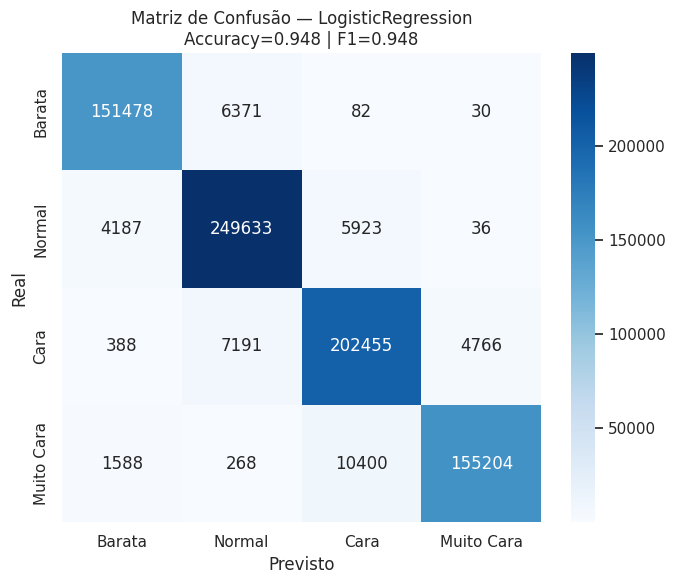

 Guardado: logreg_confusionbigdata.png


In [20]:
# ── [NOVO] Matriz de Confusão ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_te_c, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Barata','Normal','Cara','Muito Cara'],
            yticklabels=['Barata','Normal','Cara','Muito Cara'])
ax.set_title(f'Matriz de Confusão — LogisticRegression\nAccuracy={acc_lr:.3f} | F1={f1_lr:.3f}')
ax.set_ylabel('Real')
ax.set_xlabel('Previsto')
plt.tight_layout()
plt.savefig('./logreg_confusionbigdata.png', dpi=150)
plt.show()
print(" Guardado: logreg_confusionbigdata.png")

18.2.4  **Modelo 3 — Dataset Pequeno — Iris (Validação do Pipeline)**

Usamos o Iris para verificar que o pipeline ML funciona antes de escalar para o NYC Taxi.

In [21]:
# ============================================================
# DATASET IRIS
# ============================================================

iris = load_iris()
X = iris.data
y = iris.target

# split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling (importante para LR)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

# ============================================================
# GRID (reduzido como o teu original)
# ============================================================

param_lr = {
    'C': [0.1, 1.0],
    'solver': ['lbfgs'],
    'max_iter': [500],
}

lr_base = LogisticRegression(
    multi_class='auto',
    random_state=42,
    n_jobs=1
)

lr_search = GridSearchCV(
    lr_base,
    param_lr,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1,
    verbose=0
)

# ============================================================
# TRAIN + TIME
# ============================================================

t0 = time.perf_counter()
lr_search.fit(X_tr_sc, y_tr)
t_lr_iris = time.perf_counter() - t0

melhor_lr = lr_search.best_estimator_
y_pred_lr = melhor_lr.predict(X_te_sc)

# ============================================================
# MÉTRICAS
# ============================================================

acc_lr  = accuracy_score(y_te, y_pred_lr)
prec_lr = precision_score(y_te, y_pred_lr, average='weighted', zero_division=0)
rec_lr  = recall_score(y_te, y_pred_lr, average='weighted', zero_division=0)
f1_lr   = f1_score(y_te, y_pred_lr, average='weighted', zero_division=0)

# ============================================================
# OUTPUT
# ============================================================

print(f"\nMelhor hiperparâmetros: {lr_search.best_params_}")
print(f"Accuracy CV           : {lr_search.best_score_:.4f}")
print(f"Tempo treino          : {t_lr_iris:.2f}s")

print("\nMétricas no TESTE:")
print(f"Accuracy  : {acc_lr:.4f}")
print(f"Precision : {prec_lr:.4f}")
print(f"Recall    : {rec_lr:.4f}")
print(f"F1-score  : {f1_lr:.4f}")

print("\nClassification report:")
print(classification_report(y_te, y_pred_lr, target_names=iris.target_names))

# ============================================================
# REGISTO PARA TUA TABELA FINAL
# ============================================================

resultados_ml.append({
    'Modelo': 'LogisticRegression (Iris)',
    'Tipo': 'Classificação',
    'RMSE': None,
    'MAE': None,
    'R²': None,
    'Accuracy': round(acc_lr, 4),
    'F1': round(f1_lr, 4),
    'Tempo treino (s)': round(t_lr_iris, 2)
})


Melhor hiperparâmetros: {'C': 1.0, 'max_iter': 500, 'solver': 'lbfgs'}
Accuracy CV           : 0.9583
Tempo treino          : 0.05s

Métricas no TESTE:
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333
F1-score  : 0.9333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



18.3  **Resultado e Análise**

In [22]:
# ── [NOVO] Tabela Final — Métricas ML ───────────────────────
df_ml_res = pd.DataFrame(resultados_ml)
print("=" * 70)
print(" TABELA FINAL — MÉTRICAS DE MACHINE LEARNING")
print("=" * 70)
display(df_ml_res)
df_ml_res.to_csv("resultado_MLbigdata.csv")

 TABELA FINAL — MÉTRICAS DE MACHINE LEARNING


,Modelo,Tipo,RMSE,MAE,R²,Accuracy,F1,Tempo treino (s)
0,XGBRegressor,Regressão,3.8475,1.1372,0.9504,NaN,NaN,387.76
1,LogisticRegression,Classificação,NaN,NaN,NaN,0.9485,0.9485,493.64
2,LogisticRegression (Iris),Classificação,NaN,NaN,NaN,0.9333,0.9333,0.05



- **XGBRegressor**

O modelo XGBoost apresentou o melhor desempenho global na tarefa de regressão:

- R² = 0.9504, indicando excelente capacidade explicativa
- RMSE = 3.8475, representando melhoria face à versão com dataset menor
- MAE = 1.1372, erro médio reduzido


O aumento do dataset melhorou a capacidade de generalização




A relação entre features e target tornou-se mais estável com mais dados

- **LogisticRegression**

O modelo de classificação apresentou:

- Accuracy ≈ 0.9485
- F1-score ≈ 0.9485



Performance praticamente estável face à versão anterior

Apesar do aumento massivo do dataset (de ~40k → 4M),
a accuracy manteve-se praticamente igual
Isto indica:
- o problema de classificação já estava saturado
- mais dados aumentam custo computacional, mas não necessariamente desempenho


**Impacto do aumento de escala**

O fator mais relevante desta versão não foi a melhoria de métricas, mas sim:

Tempo de treino
- XGBRegressor: ~454 s
- LogisticRegression: ~522 s

 Conclusão:

- O aumento de dados teve impacto drástico no tempo de execução
- O custo cresce aproximadamente de forma quase linear com o volume de dados.

**Próximo Notebook:**

  6.2-experimento_MLGPU.ipynb - Pipeline de Machine Learning com Cudf